In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
import seaborn as sns

In [2]:
#tickers = ["SPY", "DIA", "QQQ", "IWM"]
# Define the index tickers and their descriptive names
recognized_tickers = {
    "^GSPC": "S&P 500",
    "^DJI": "Dow Jones",
    "^NDX": "Nasdaq 100",
    "^RUT": "Russell 2000"
}

# Download data for the indices
tickers_indices = list(recognized_tickers.keys())  # Get the list of ticker symbols
data_indices = yf.download(tickers_indices, period="max")
daily_close = data_indices['Close']

# Rename the columns for better understanding
daily_close.rename(columns=recognized_tickers, inplace=True)
tickers_descriptive = list(recognized_tickers.values())

# Now 'daily_close' DataFrame has columns with descriptive names
print(daily_close.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  4 of 4 completed

Ticker      Dow Jones    S&P 500  Nasdaq 100  Russell 2000
Date                                                      
1927-12-30        NaN  17.660000         NaN           NaN
1928-01-03        NaN  17.760000         NaN           NaN
1928-01-04        NaN  17.719999         NaN           NaN
1928-01-05        NaN  17.549999         NaN           NaN
1928-01-06        NaN  17.660000         NaN           NaN



C:\Users\binia\AppData\Local\Temp\ipykernel_9124\1430364607.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_close.rename(columns=recognized_tickers, inplace=True)


In [3]:
first_valid_dates = daily_close.notna().idxmax()
print(first_valid_dates)
latest_start = first_valid_dates.max()
print(f"\nThe latest start date among the ETFs is: {latest_start}")

Ticker
Dow Jones      1992-01-02
S&P 500        1927-12-30
Nasdaq 100     1985-10-01
Russell 2000   1987-09-10
dtype: datetime64[ns]

The latest start date among the ETFs is: 1992-01-02 00:00:00


In [4]:
daily_close = daily_close[daily_close.index >= latest_start]
daily_close.head()

Ticker,Dow Jones,S&P 500,Nasdaq 100,Russell 2000
Date,,,,
1992-01-02,3172.399902,417.260010,333.364990,188.750000
1992-01-03,3201.500000,419.339996,334.825012,192.089996
1992-01-06,3200.100098,417.959991,336.894989,194.330002
1992-01-07,3204.800049,417.399994,339.644989,195.770004
1992-01-08,3203.899902,418.100006,344.290009,198.080002


In [5]:
def aggregate_data(df, frequency='W'):
    """Aggregates daily data to weekly or monthly."""
    return df.resample(frequency).last()


In [6]:
def plot_with_markers(df, ticker, start_date=None, end_date=None, aggregation=None):
    """Plots the closing price with markers based on the conditions (potential downward reversal)
       within a specified date range."""
    df_to_plot = df[[ticker]].copy()

    if start_date or end_date:
        df_to_plot = df_to_plot[start_date:end_date].copy()
        date_range_str = f' ({df_to_plot.index.min().strftime("%Y-%m-%d")} to {df_to_plot.index.max().strftime("%Y-%m-%d")})'
    else:
        date_range_str = ''

    if aggregation:
        df_agg = aggregate_data(df_to_plot, frequency=aggregation)
    else:
        df_agg = df_to_plot.copy()

    future_window = 252 if aggregation is None else 52 if aggregation == 'W' else 12 # Approx. trading days/weeks/months
    previous_window = 126 if aggregation is None else 26 if aggregation == 'W' else 6 # Approx. trading days/weeks/months

    markers_condition = []
    for i in range(len(df_agg)):
        current_price = df_agg[ticker].iloc[i]
        future_prices = df_agg[ticker].iloc[i+1:i+future_window+1]
        previous_prices = df_agg[ticker].iloc[max(0, i-previous_window):i]

        future_condition = True
        if not future_prices.empty:
            future_condition = all(current_price < future_prices)
        else:
            future_condition = False # Not enough future data

        previous_condition = True
        if not previous_prices.empty:
            previous_condition = not (current_price > previous_prices.min())
        else:
            previous_condition = True # Not enough previous data, so we allow the marker

        markers_condition.append(future_condition and previous_condition)

    markers_condition_series = pd.Series(markers_condition, index=df_agg.index)
    marker_dates = df_agg[markers_condition_series].index
    marker_prices = df_agg[ticker][markers_condition_series]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df_agg.index, df_agg[ticker], label=ticker, alpha=0.7)
    ax.scatter(marker_dates, marker_prices, color='blue', marker='o', s=50, label='Potential Downward Reversal')
    for date, price in zip(marker_dates, marker_prices):
        ax.text(date, price - (0.02 * df_agg[ticker].max()),
                 date.strftime('%Y-%m'),
                 ha='center', va='top', fontsize=8)

    ax.set_xlabel('Date')
    ax.set_ylabel('Closing Price')
    ax.set_title(f'{ticker} Closing Price with Potential Downward Reversal Markers{date_range_str}')
    ax.legend()
    ax.grid(True)
    fig.tight_layout()

    return fig, ax, marker_dates, marker_prices

In [26]:
def plot_markers_with_color(ax, all_marker_data, ticker, price_data_max):
    """Plots markers with color coding and a sorted legend."""
    marker_dates = all_marker_data[ticker]['dates']
    marker_prices = all_marker_data[ticker]['prices']

    legend_data = {}

    for date, price in zip(marker_dates, marker_prices):
        same_month_year_count = 0
        for other_ticker, data in all_marker_data.items():
            if other_ticker != ticker:
                for other_date in data['dates']:
                    if date.year == other_date.year and date.month == other_date.month:
                        same_month_year_count += 1
                        break

        marker_color = 'blue'
        label = 'Local Low'
        sort_order = 0
        if same_month_year_count == 3:
            marker_color = 'magenta'
            label = 'Low in Same Month/Year (All 4 Indices)'
            sort_order = 3
        elif same_month_year_count == 2:
            marker_color = 'orange'
            label = 'Low in Same Month/Year (3 of 4 Indices)'
            sort_order = 2
        elif same_month_year_count == 1:
            marker_color = 'cyan'
            label = 'Low in Same Month/Year (2 of 4 Indices)'
            sort_order = 1

        scatter = ax.scatter(date, price, color=marker_color, marker='o', s=50, label=label)
        ax.text(date, price - (0.02 * price_data_max),
                date.strftime('%Y-%m-%d'),
                ha='center', va='top', fontsize=8)
        legend_data[label] = (scatter, sort_order)

    # Sort legend entries based on the sort_order
    sorted_legend_items = sorted(legend_data.items(), key=lambda item: item[1][1])

    handles = [item[1][0] for item in sorted_legend_items]
    labels = [item[0] for item in sorted_legend_items]

    ax.legend(handles, labels, loc='upper left', fontsize='small')

    return ax

In [27]:
def identify_low_markers(df, ticker, start_date=None, end_date=None, aggregation=None):
    """Identifies local low markers and returns the marker dates and prices."""
    df_to_plot = df[[ticker]].copy()

    if start_date or end_date:
        df_to_plot = df_to_plot[start_date:end_date].copy()
    if aggregation:
        df_agg = aggregate_data(df_to_plot, frequency=aggregation)
    else:
        df_agg = df_to_plot.copy()

    future_window = 252 if aggregation is None else 52 if aggregation == 'W' else 12
    previous_window = 126 if aggregation is None else 26 if aggregation == 'W' else 6

    markers_condition = []
    for i in range(len(df_agg)):
        current_price = df_agg[ticker].iloc[i]
        future_prices = df_agg[ticker].iloc[i+1:i+future_window+1]
        future_lowest = future_prices.min() if not future_prices.empty else float('inf')
        is_future_lowest = current_price < future_lowest
        previous_prices = df_agg[ticker].iloc[max(0, i-previous_window):i]
        previous_lowest = previous_prices.min() if not previous_prices.empty else float('inf')
        is_previous_lowest = current_price < previous_lowest
        markers_condition.append(is_future_lowest and is_previous_lowest)

    markers_condition_series = pd.Series(markers_condition, index=df_agg.index)
    marker_dates = df_agg[markers_condition_series].index
    marker_prices = df_agg[ticker][markers_condition_series]

    return marker_dates, marker_prices

Identifying local low markers...

Plotting with color coding based on overlap...


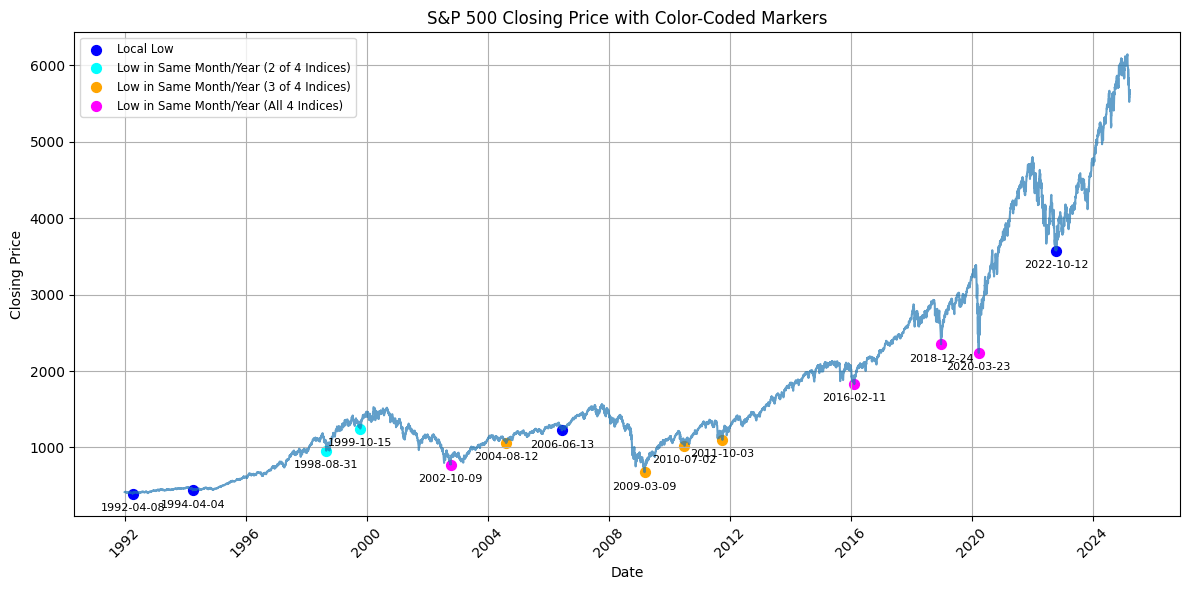

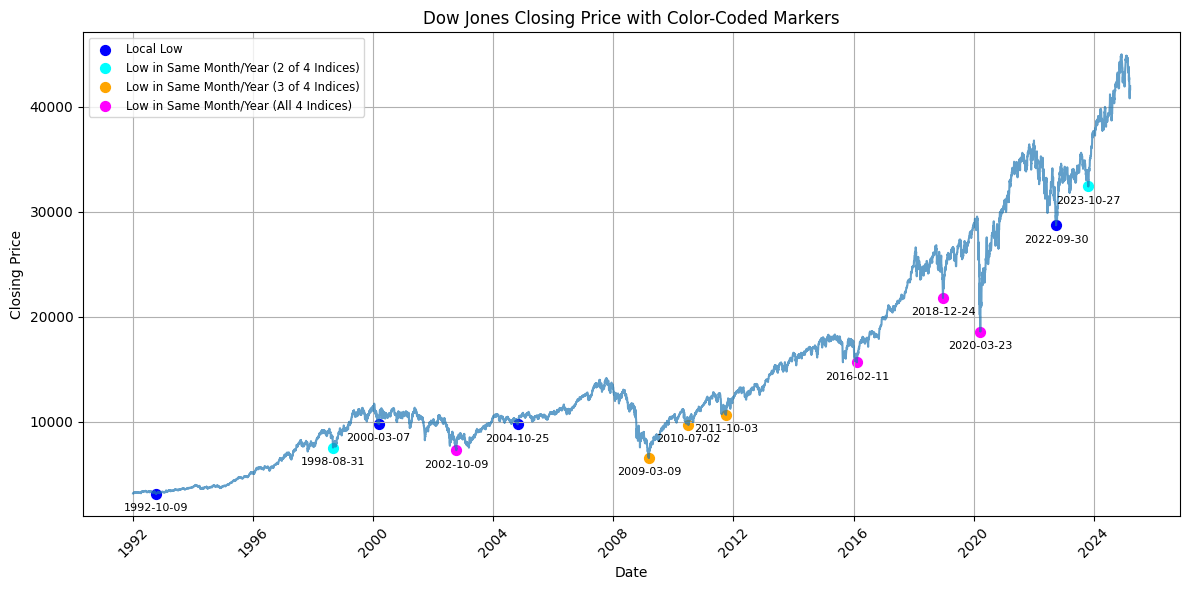

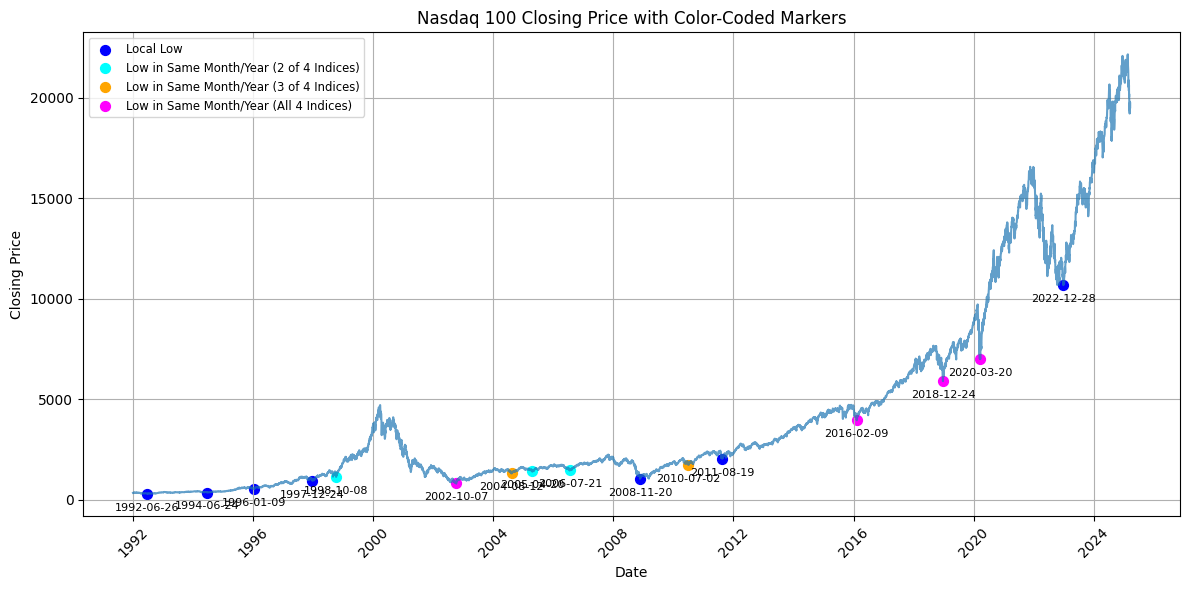

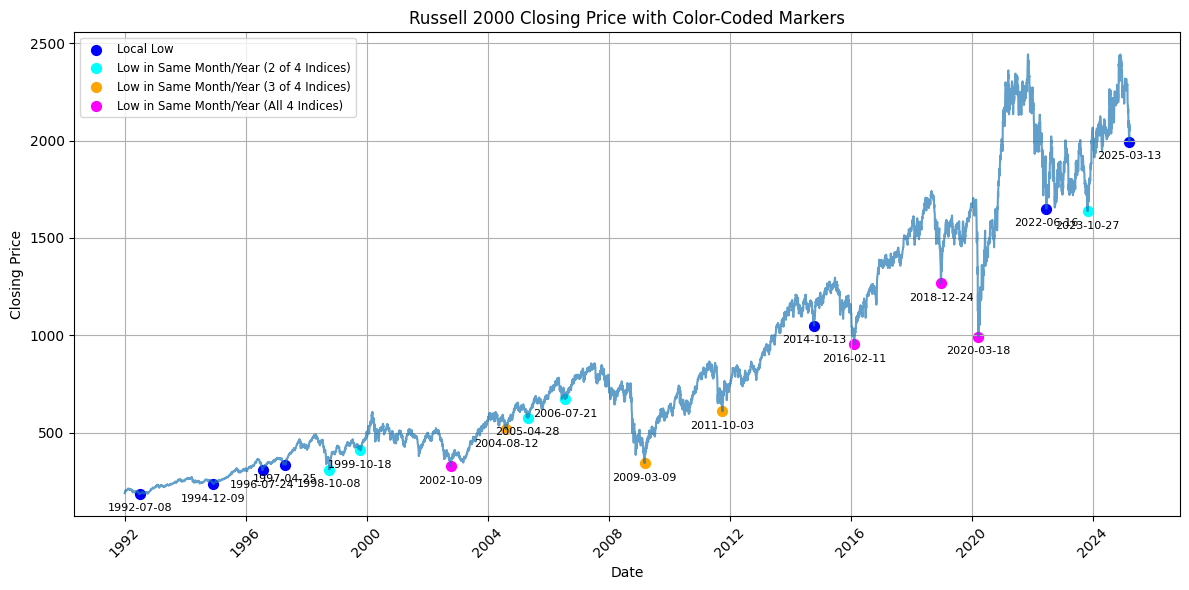

In [28]:
# Define a zoom-in date range as needed
zoom_start_date = "2001-12-01"
zoom_end_date = "2008-12-31"

# Plot each ticker with daily data

all_marker_data = {}
price_data_max = {}

# Identify markers
print("Identifying local low markers...")
for ticker in tickers_descriptive:
    marker_dates, marker_prices = identify_low_markers(daily_close, ticker)
    all_marker_data[ticker] = {'dates': marker_dates, 'prices': marker_prices}
    price_data_max[ticker] = daily_close[ticker].max()

# Plot with color coding
print("\nPlotting with color coding based on overlap...")
for ticker in tickers_descriptive:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(daily_close.index, daily_close[ticker], label=ticker, alpha=0.7)
    ax.set_xlabel('Date')
    ax.set_ylabel('Closing Price')
    ax.set_title(f'{ticker} Closing Price with Color-Coded Markers')
    ax.legend()
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

    plot_markers_with_color(ax, all_marker_data, ticker, price_data_max[ticker])
    fig.tight_layout()
    plt.show()



In [29]:
def days_to_highest_close(df, ticker, marker_dates):
    """
    Calculates the number of days between each marker and the highest closing price
    reached between that marker and the next marker.

    Args:
        df (pd.DataFrame): DataFrame containing the closing prices.
        ticker (str): The ticker symbol (column name).
        marker_dates (pd.DatetimeIndex): The dates of the identified markers.

    Returns:
        pd.DataFrame: DataFrame with marker dates as index and columns for
                      'next_marker_date', 'highest_close_date', and 'days_to_highest_close'.
                      Returns an empty DataFrame if there are fewer than 2 markers.
    """
    if len(marker_dates) < 2:
        return pd.DataFrame()

    results = []
    for i in range(len(marker_dates) - 1):
        current_marker_date = marker_dates[i]
        next_marker_date = marker_dates[i + 1]

        # Select the price data between the current and next marker
        relevant_prices = df[ticker][current_marker_date:next_marker_date]

        if not relevant_prices.empty:
            highest_close = relevant_prices.max()
            highest_close_date = relevant_prices[relevant_prices == highest_close].index[0]
            days_diff = (highest_close_date - current_marker_date).days
            results.append({
                'marker_date': current_marker_date,
                'next_marker_date': next_marker_date,
                'highest_close_date': highest_close_date,
                'days_to_highest_close': days_diff
            })
        else:
            results.append({
                'marker_date': current_marker_date,
                'next_marker_date': next_marker_date,
                'highest_close_date': None,
                'days_to_highest_close': None
            })

    return pd.DataFrame(results).set_index('marker_date')

In [34]:
all_tickers_highest_close_info = []

for ticker in tickers_descriptive:
    marker_dates = all_marker_data[ticker]['dates']
    if len(marker_dates) >= 2:
        highest_close_info = days_to_highest_close(daily_close, ticker, marker_dates)
        highest_close_info['ticker'] = ticker  # Add a ticker column
        all_tickers_highest_close_info.append(highest_close_info)
    else:
        print(f"\nFewer than 2 markers found for {ticker}, skipping highest close analysis.")

if all_tickers_highest_close_info:
    combined_highest_close_df = pd.concat(all_tickers_highest_close_info)
    
else:
    print("\nNo tickers had enough markers for the highest close analysis.")

combined_highest_close_df.head()

,next_marker_date,highest_close_date,days_to_highest_close,ticker
marker_date,,,,
1992-04-08,1994-04-04,1994-02-02,665,S&P 500
1994-04-04,1998-08-31,1998-07-17,1565,S&P 500
1998-08-31,1999-10-15,1999-07-16,319,S&P 500
1999-10-15,2002-10-09,2000-03-24,161,S&P 500
2002-10-09,2004-08-12,2004-02-11,490,S&P 500


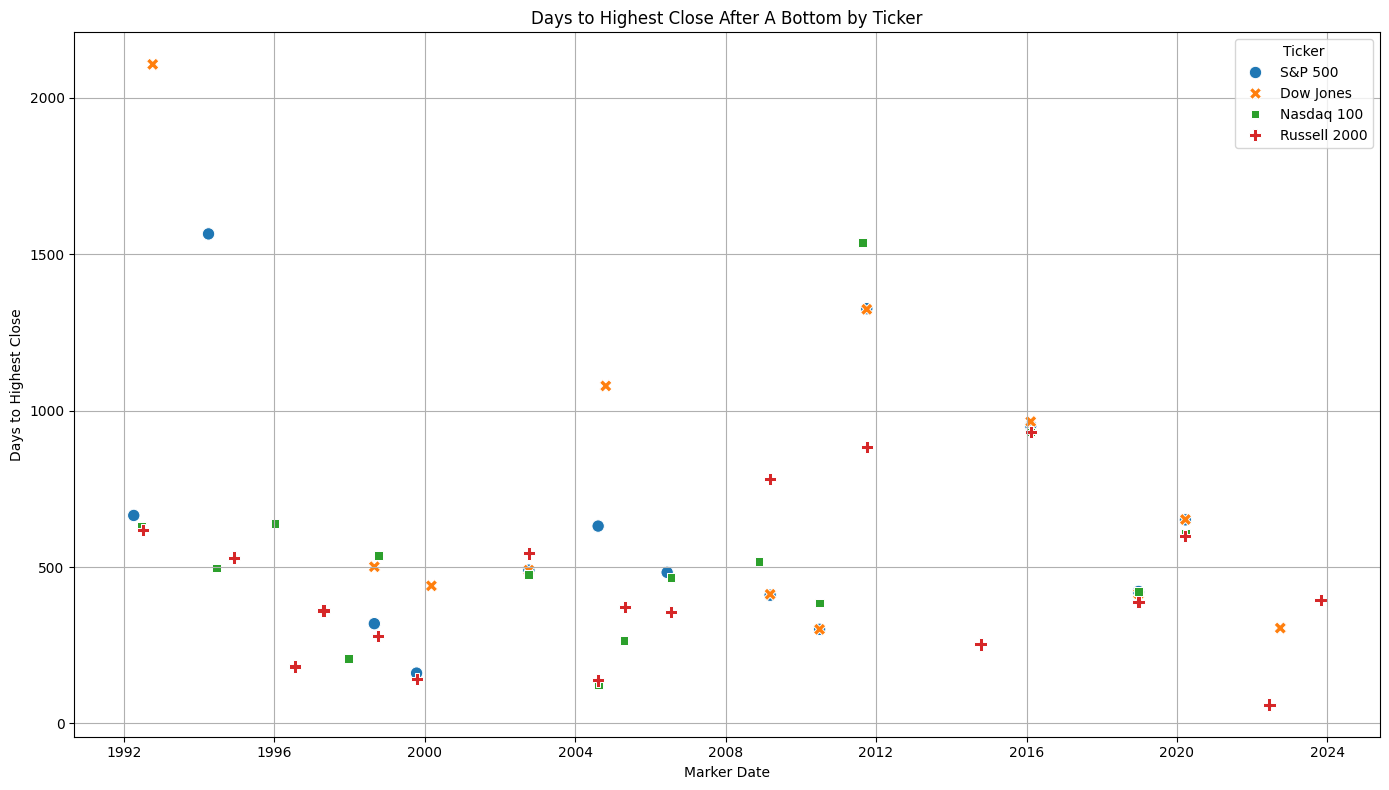

In [38]:
if 'combined_highest_close_df' in locals() and not combined_highest_close_df.empty:
    plt.figure(figsize=(14, 8))
    sns.scatterplot(data=combined_highest_close_df, x='marker_date', y='days_to_highest_close', hue='ticker', style='ticker', s=80)
    plt.title('Days to Highest Close After A Bottom by Ticker')
    plt.xlabel('Marker Date')
    plt.ylabel('Days to Highest Close')
    plt.legend(title='Ticker')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("The 'combined_highest_close_df' DataFrame is not available or is empty. Please run the previous analysis to generate it.")

In [40]:
def identify_high_markers(df, ticker, start_date=None, end_date=None, aggregation=None):
    """Identifies potential downward reversal high markers."""
    df_to_plot = df[[ticker]].copy()

    if start_date or end_date:
        df_to_plot = df_to_plot[start_date:end_date].copy()
    if aggregation:
        df_agg = aggregate_data(df_to_plot, frequency=aggregation)
    else:
        df_agg = df_to_plot.copy()

    future_window = 252 if aggregation is None else 52 if aggregation == 'W' else 12
    previous_window = 126 if aggregation is None else 26 if aggregation == 'W' else 6

    markers_condition = []
    for i in range(len(df_agg)):
        current_price = df_agg[ticker].iloc[i]
        future_prices = df_agg[ticker].iloc[i+1:i+future_window+1]
        previous_prices = df_agg[ticker].iloc[max(0, i-previous_window):i]

        future_condition = True
        if not future_prices.empty:
            future_condition = all(current_price > future_prices)
        else:
            future_condition = False # Not enough future data

        previous_condition = True
        if not previous_prices.empty:
            previous_condition = not (current_price < previous_prices.max())
        else:
            previous_condition = True # Not enough previous data, so we allow the marker

        markers_condition.append(future_condition and previous_condition)

    markers_condition_series = pd.Series(markers_condition, index=df_agg.index)
    marker_dates = df_agg[markers_condition_series].index
    marker_prices = df_agg[ticker][markers_condition_series]

    return marker_dates, marker_prices

In [43]:
def plot_high_markers_with_color(ax, all_high_marker_data, ticker, price_data_max):
    """Plots high markers with color coding based on year and month overlap."""
    marker_dates = all_high_marker_data[ticker]['dates']
    marker_prices = all_high_marker_data[ticker]['prices']

    for date, price in zip(marker_dates, marker_prices):
        same_month_year_count = 0
        for other_ticker, data in all_high_marker_data.items():
            if other_ticker != ticker:
                for other_date in data['dates']:
                    if date.year == other_date.year and date.month == other_date.month:
                        same_month_year_count += 1
                        break  # Only count once per other ticker

        marker_color = 'red'  # Default color for a high marker

        if same_month_year_count == 1:
            marker_color = 'cyan'
        elif same_month_year_count == 2:
            marker_color = 'orange'
        elif same_month_year_count == 3:
            marker_color = 'magenta'

        ax.scatter(date, price, color=marker_color, marker='^', s=50)
        ax.text(date, price + (0.01 * price_data_max),
                date.strftime('%Y-%m-%d'),
                ha='center', va='bottom', fontsize=8)

    return ax

Identifying potential downward reversal high markers...

Plotting high markers with color coding based on overlap...


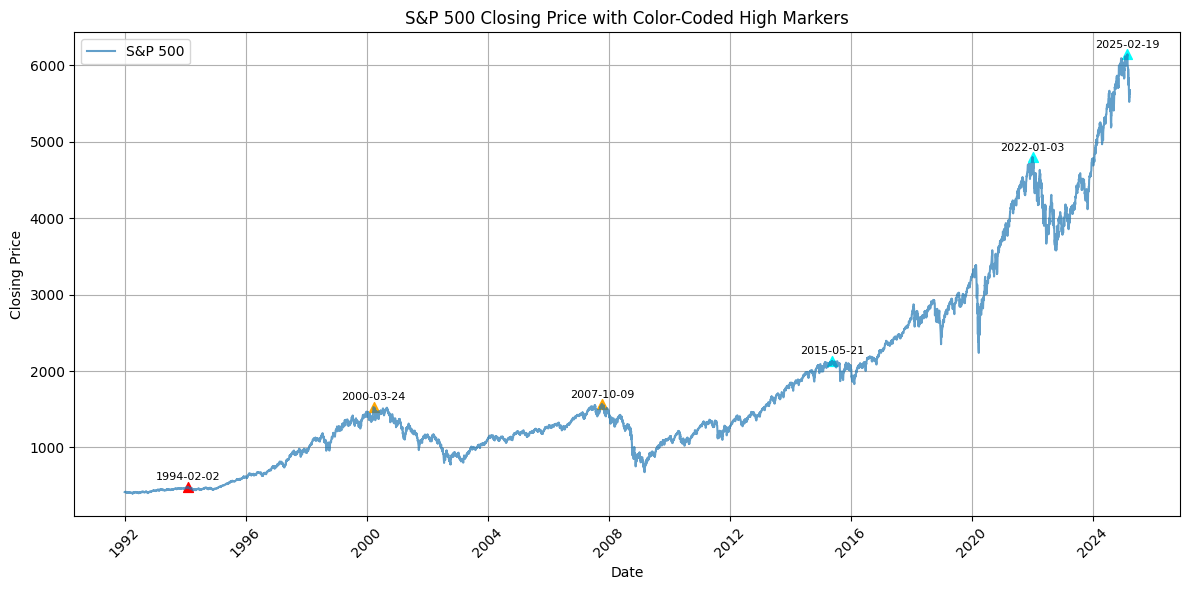

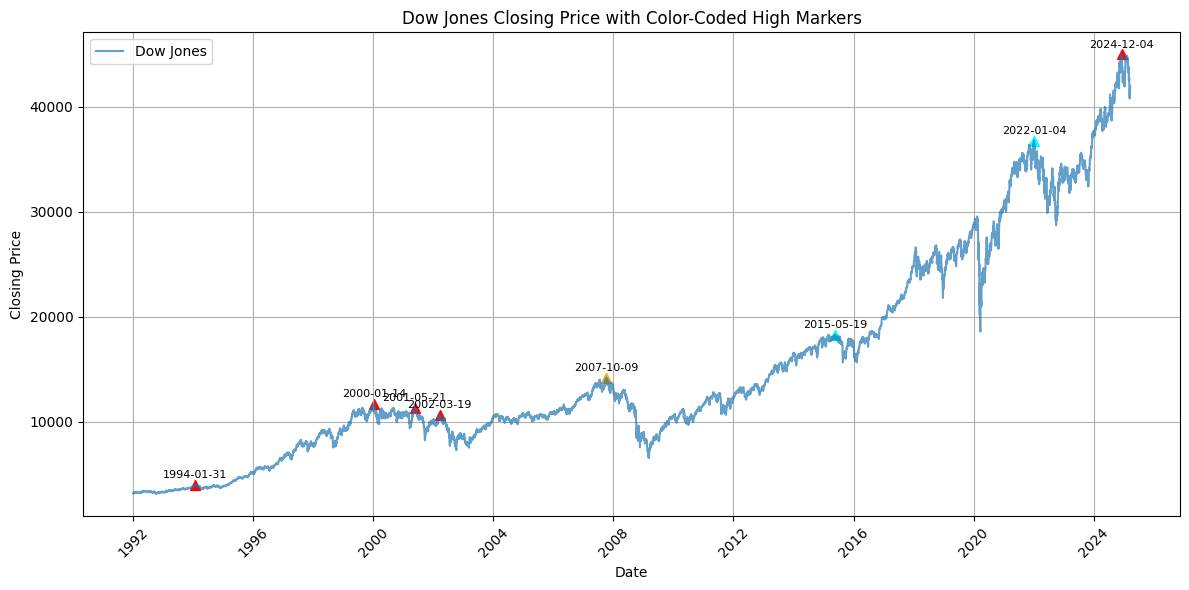

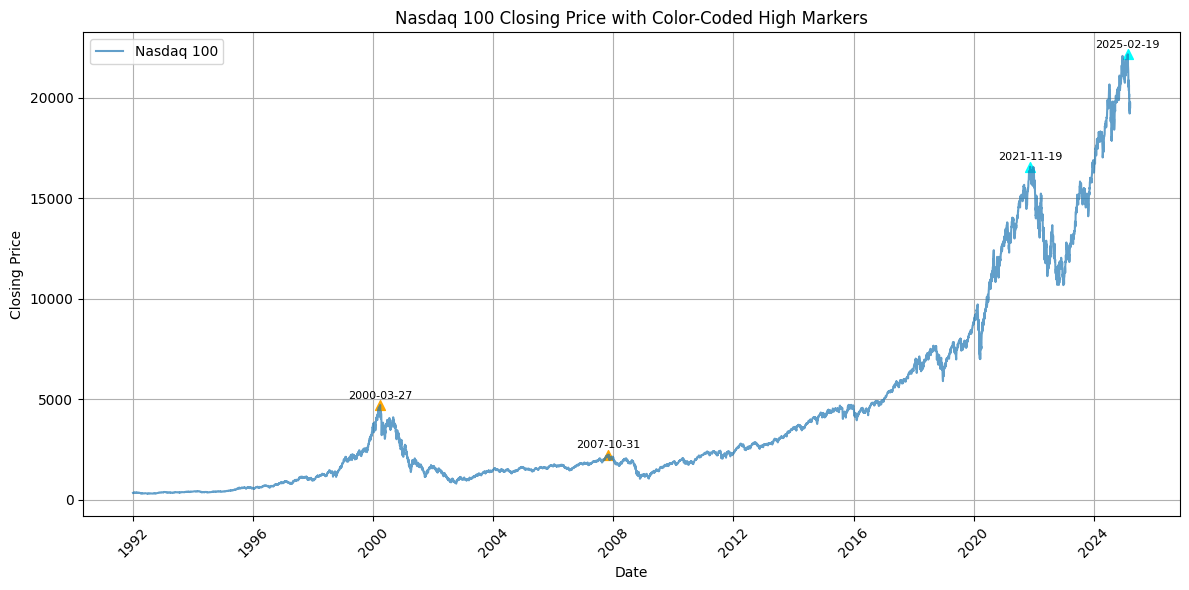

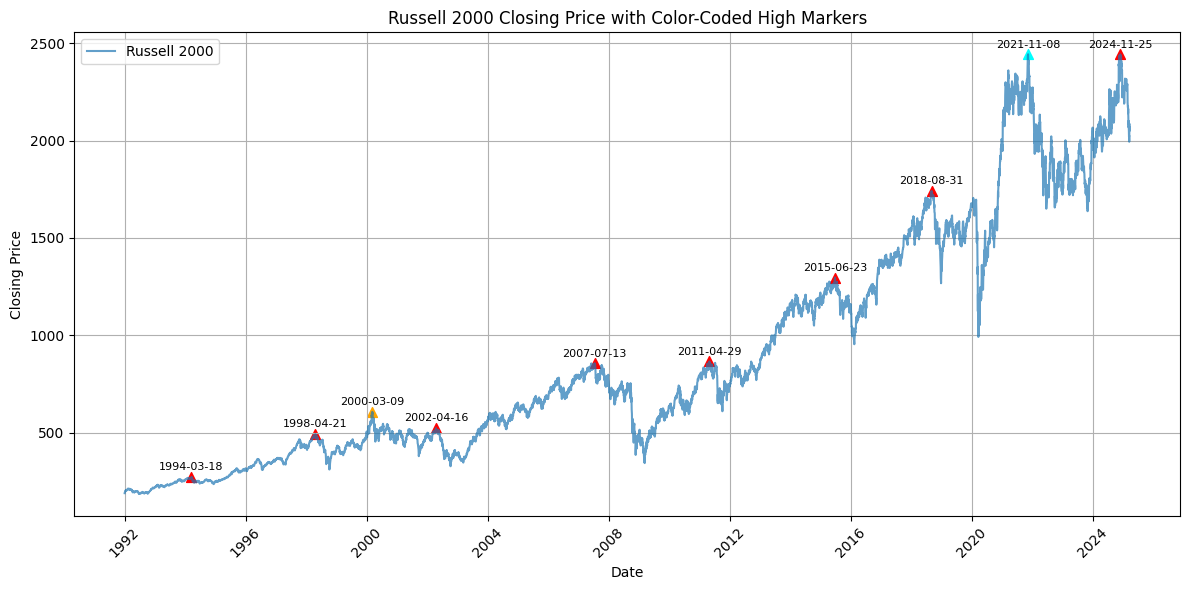

In [45]:
all_high_marker_data = {}
price_data_max_high = {}

# Identify high markers
print("Identifying potential downward reversal high markers...")
for ticker in tickers_descriptive:
    high_marker_dates, high_marker_prices = identify_high_markers(daily_close, ticker)
    all_high_marker_data[ticker] = {'dates': high_marker_dates, 'prices': high_marker_prices}
    price_data_max_high[ticker] = daily_close[ticker].max()



# Plot with color coding
print("\nPlotting high markers with color coding based on overlap...")
for ticker in tickers_descriptive:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(daily_close.index, daily_close[ticker], label=ticker, alpha=0.7)
    ax.set_xlabel('Date')
    ax.set_ylabel('Closing Price')
    ax.set_title(f'{ticker} Closing Price with Color-Coded High Markers')
    ax.legend()
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

    plot_high_markers_with_color(ax, all_high_marker_data, ticker, price_data_max_high[ticker])
    fig.tight_layout()
    plt.show()

In [46]:
all_tickers_lowest_close_after_colored_high_info = []

for ticker in tickers_descriptive:
    high_marker_dates = all_high_marker_data[ticker]['dates']
    if not high_marker_dates.empty:
        lowest_close_info = days_to_lowest_close_after_high(daily_close, ticker, high_marker_dates)
        lowest_close_info['ticker'] = ticker
        all_tickers_lowest_close_after_colored_high_info.append(lowest_close_info)
    else:
        print(f"\nNo high markers found for {ticker}, skipping lowest close analysis.")

if all_tickers_lowest_close_after_colored_high_info:
    combined_lowest_close_after_colored_high_df = pd.concat(all_tickers_lowest_close_after_colored_high_info)
    print("\nDays to Lowest Close After Color-Coded High Markers for All Tickers:\n", combined_lowest_close_after_colored_high_df)
else:
    print("\nNo high markers found for any tickers for the lowest close analysis.")

NameError: name 'days_to_lowest_close_after_high' is not defined